# Lab 01: Data wrangling and EDA

**You should add this to a personal Github repo and submit the link to the repo in Canvas.** Add your name to the top of this document and anyone you worked with.

The goal of this lab is to practice working with datasets using Pandas and explore a dataset with plotting and basic statistics. In particular, we will look at a plot to track flows (association between two categoricals): the alluvial diagram.

Here is your lab prompt: You are advising the University of Virginia’s Office of Development on opportunities to expand philanthropic support from international sources. Using the foreign-giving data provided, develop a short strategic plan identifying the countries, institutions, or donor segments UVA should prioritize for future engagement.

Your recommendations should be evidence-based. Use the data to identify patterns in giving, compare potential sources of support, and explain why particular markets or institutions appear especially promising. Support your conclusions with appropriate summaries and visualizations, and translate your findings into a small set of concrete recommendations for the Director of Development.,

1. In your first .ipynb or .py file called **initial_analysis** complete the following steps:
     1. Load the Foreign Gifts data.
     2. Describe the differences between different classes of gift types.
     3. Answer the following questions:
         1. Which country gives the most money in total?
         2. Which country initiates the most gifts by count?
         3. Which country gives the largest gifts on average?
         4. Which institution receive the most money in total?
         5. Which institution receive the greatest number of gifts by count?
         6. What is the average amount each university receives? Median amount? If they are different why?
         7. What is the largest flow of a single country to a single institution?
         8. Which are the top giftors to US academic institutions?
 2. In a new .ipynb/.py file called **uva_analysis**, analyze foreign giving to UVA. Compare UVA to appropriate peer institutions and the market overall. Propose a strategy for finding new sources of foreign money and provide a quantitative analysis.
 3. In a document file (.doc, .docx, .pdf, etc.), summarize your findings:
     1. Executive Summary: What are your main findings and recommendations, in a single paragraph?
     2. Summarize the results of your initial analyses of overall giving and giving to UVA (1-3 paragraphs).
     3. Describe a strategy for finding new potential sources of money for UVA. What countries or institutions should UVA target, and why? (1-3 paragraphs)
     4. Conclude with a summary of UVA's prospects for increasing foreign giving. (1 paragraph).

 In total, your submission repo contain submit at least .ipynb/.py analysis files and a document file with your report (.doc, .docx, .pdf, etc.). If you divide the work among members of a group, make sure that you understand the code being written and submitted by the other members of your group.



Credit to the Pandas cheat sheet found at the following repository for help with using Pandas functions: https://github.com/pandas-dev/pandas/blob/main/doc/cheatsheet/Pandas_Cheat_Sheet.pdf

## The standard stack: importing packages + reading in the data

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


# Question 1.2: The different classes of gift types

In [3]:
print(df["Gift Type"].value_counts())

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64


There appears to be Contracts, Monetary Gifts, and Real Estate as gift types.

Contracts seem like a structured agreement to use the provided money in the contract for a specified purpose.

Monetary Gifts seem like gifts given to a organization that are able to be used however the organization would like.

Real Estate seems like the gift of Real Estate to a organization, thus classifying it seperatley from Monetary Gifts or Contracts.

## Groupby

As we learned, `.groupby` is a super useful way to aggregate the data and explore summary statistics. We can assign the output to a new dataframe, just taking the n largest amounts. Resetting the index just changes the index to integers starting at 0. 

<div class="alert alert-block alert-warning">
<b>Question 1:</b>  Which country gives the most money, in total?
</div>


In [ ]:
country_money_analysis = df.groupby("Country of Giftor").sum("Foreign Gift Amount")
country_money_analysis.sort_values("Foreign Gift Amount", ascending= False).head(5)

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
Country of Giftor,,,,
QATAR,14133760,207860000,29707239,2706240869
ENGLAND,47713393,861644700,156432837,1464906771
CHINA,33468243,601615400,105733871,1237952112
SAUDI ARABIA,20193035,355691800,69276531,1065205930
BERMUDA,2126107,31117600,5021524,899593972


According to the analysis, Qatar gives the most amount of money in total, with almost double the amount of second place England

<div class="alert alert-block alert-warning">
<b>Question 2:</b>  Which country initiates the most gifts, by count?
</div>


In [10]:
gift_count_analysis = df.groupby("Country of Giftor").count().sort_values("ID", ascending=False)
print(gift_count_analysis.head(5)["ID"])

Country of Giftor
ENGLAND        3655
CHINA          2461
CANADA         2344
JAPAN          1896
SWITZERLAND    1676
Name: ID, dtype: int64


The analysis shows that England is the country that gives the most gifts by count.

<div class="alert alert-block alert-warning">
<b>Question 3:</b>  Which country gives the largest gifts, on average?
</div>

In [14]:
# Finding the mean of the gift amount given for each country.

largest_average_gifts = df.groupby("Country of Giftor").mean("Foreign Gift Amount")
print(largest_average_gifts.sort_values("Foreign Gift Amount", ascending = False).head(5))

                             ID          OPEID  Foreign Gift Received Date  \
Country of Giftor                                                            
BERMUDA            18171.854701  265962.393162                42919.008547   
ECUADOR            12562.571429  200914.285714                42416.285714   
QATAR              20395.036075  299942.279942                42867.588745   
ANTIGUA            27812.000000  963500.000000                43830.000000   
JERSEY             13030.333333  189716.666667                43307.333333   

                   Foreign Gift Amount  
Country of Giftor                       
BERMUDA                   7.688837e+06  
ECUADOR                   3.985140e+06  
QATAR                     3.905109e+06  
ANTIGUA                   3.435545e+06  
JERSEY                    3.064589e+06  


The country that gives the largest gifts on average appears to be Bermuda.

## Ordering by institution

<div class="alert alert-block alert-warning">
<b>Question 4:</b>  Which institution receive the most money, in total?
</div>

<div class="alert alert-block alert-warning">
<b>Question 5:</b>  Which institution receive the greatest number of gifts, by count?
</div>

Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

In [26]:
# Question 4: Finding the institution which recieves the most money in total:

institution_by_money_recieved = df.groupby("Institution Name").sum("Foreign Gift Amount")
print(institution_by_money_recieved.sort_values('Foreign Gift Amount', ascending= False)["Foreign Gift Amount"].head(5))

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
Name: Foreign Gift Amount, dtype: int64


Carnegie Mellon University appears to recieve the most foreign aid money of institutions in the dataset.



In [5]:
# Question 5: Which institutions recieve the greatest number of gifts, by count?

# Sort values only takes a column name if there are multiple columns in the dataframe.
df = df.rename({"Institution Name" : "Institution_Name"}, axis=1)
institutional_gifts = df.groupby("Institution_Name").count()["ID"].sort_values(ascending=False).head(20)
print(institutional_gifts.sort_values(ascending=False).head(5))

Institution_Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
Name: ID, dtype: int64


UCLA appears to recieve the most number of foreign gifts in the dataset.

In [6]:
# Plotting the top 20 universities by gifts recieved using Seaborn

#help(sns.categorical)
# Head (20) does not return a dataframe.
# institutional_gifts_top_20 = institutional_gifts.sort_values(ascending=False), columns=['Institution Name', 'ID']
#df = df.rename({"Institution_Name1" : "Institution_Name"}, axis=1)
print(df.head(1))
institutional_gifts_top_20 = df[df.Institution_Name.isin(list(institutional_gifts.index))]
print(institutional_gifts_top_20.Institution_Name.unique())
print(institutional_gifts_top_20.groupby("Institution_Name").count())
seaborn_dataframe = pd.DataFrame(columns=["Institution_Name", "Institution_Count"])
seaborn_dataframe["Institution_Name"] = institutional_gifts_top_20.Institution_Name.unique()
seaborn_dataframe["Institution_Count"] = institutional_gifts_top_20.groupby("Institution_Name").count()["ID"]
test_holder = institutional_gifts_top_20.groupby("Institution_Name").count().to_dict()
print(test_holder)
#sns.stripplot(institutional_gifts_top_20, x = institutional_gifts_top_20.Institution_Name.unique(), y = institutional_gifts_top_20.groupby("Institution_Name").count())

   ID   OPEID               Institution_Name          City State  \
0   1  102000  Jacksonville State University  Jacksonville    AL   

   Foreign Gift Received Date  Foreign Gift Amount      Gift Type  \
0                       43738               250000  Monetary Gift   

  Country of Giftor Giftor Name  
0             CHINA         NaN  
['Arizona State University' 'California Institute of Technology'
 'Stanford University' 'University of California, Berkeley'
 'University of California, Los Angeles' 'Colorado State University'
 'University of Colorado Boulder' 'Yale University'
 'University of Chicago (The)' 'Johns Hopkins University'
 'Harvard University' 'Massachusetts Institute of Technology'
 'University of Michigan - Ann Arbor'
 'Columbia University in the City of New York' 'Cornell University'
 'Ohio State University (The)' 'University of Pennsylvania'
 'Texas A&M University' 'University of Texas at Austin'
 'University of Colorado Denver']
                                  

{'Arizona State University': 400, 'California Institute of Technology': 2502, 'Colorado State University': 379, 'Columbia University in the City of New York': 1127, 'Cornell University': 653, 'Harvard University': 453, 'Johns Hopkins University': 899, 'Massachusetts Institute of Technology': 582, 'Ohio State University (The)': 1014, 'Stanford University': 668, 'Texas A&M University': 376, 'University of California, Berkeley': 394, 'University of California, Los Angeles': 3916, 'University of Chicago (The)': 401, 'University of Colorado Boulder': 363, 'University of Colorado Denver': 436, 'University of Michigan - Ann Arbor': 715, 'University of Pennsylvania': 625, 'University of Texas at Austin': 377, 'Yale University': 550}
Hi
                                             Count
University of California, Los Angeles         3916
California Institute of Technology            2502
Columbia University in the City of New York   1127
Ohio State University (The)                   1014
Johns H

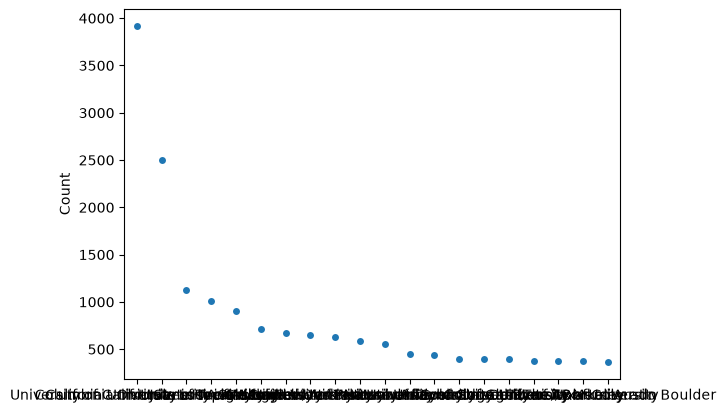

In [7]:
print(test_holder["ID"])
# How can I create a Pandas Dataframe from a dictionary?
#print(seaborn_dataframe)
seaborn_dataframe = pd.DataFrame.from_dict(test_holder["ID"], orient="index", columns=['Count'])
seaborn_dataframe = seaborn_dataframe.sort_values("Count", ascending=False)
print("Hi")
print(seaborn_dataframe)
# Plot is made!
print(sns.stripplot(seaborn_dataframe, x = list(seaborn_dataframe.index), y="Count"))
#help(pd.DataFrame.from_dict(test_holder["ID"], orient="index", columns=['Instution Name', 'Count']))

## Comparing summary statistics

<div class="alert alert-block alert-warning">
<b>Question 6:</b>  What is the average amount each university receives? Median amount? If they are different, why?
</div>

Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.


15.816881203640877


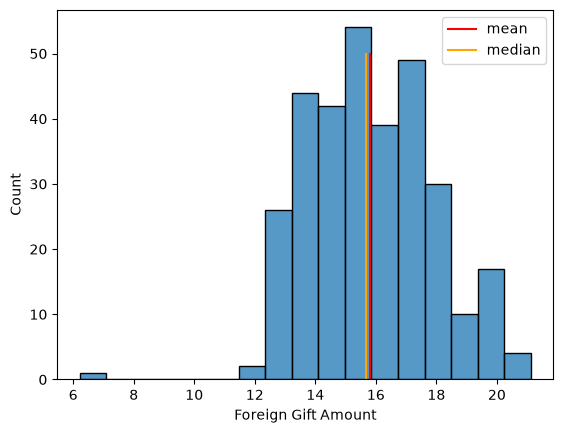

Help on function plot in module matplotlib.pyplot:

plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data: 'DataParamType' = None, **kwargs) -> 'list[Line2D]'
    Plot y versus x as lines and/or markers.

    Call signatures::

        plot([x], y, [fmt], *, data=None, **kwargs)
        plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

    The coordinates of the points or line nodes are given by *x*, *y*.

    The optional parameter *fmt* is a convenient way for defining basic
    formatting like color, marker and linestyle. It's a shortcut string
    notation described in the *Notes* section below.

    >>> plot(x, y)        # plot x and y using default line style and color
    >>> plot(x, y, 'bo')  # plot x and y using blue circle markers
    >>> plot(y)           # plot y using x as index array 0..N-1
    >>> plot(y, 'r+')     # ditto, but with red plusses

    You can use `.Line2D` properties as keyword arguments for more
    control on the a

In [81]:
# Getting the mean and median amounts that each university recieves
#print(df.groupby("Institution_Name").mean("Foreign Gift Amount"))

# Plotting mean amount:


# Now for the median
#print("Median")
#print(df.groupby("Institution_Name").median("Foreign Gift Amount"))

# Plotting the Histogram of the amount recieved by each university.
#print(df.plot.hist(by = "Foreign Gift Amount"))

df_top_20 = df.head(20)

#print(df.groupby("Institution_Name").sum("Foreign Gift Amount").plot.hist(by="Foreign Gift Amount"))
sum_of_university_gifts = df.groupby("Institution_Name").sum("Foreign Gift Amount")
sum_of_university_gifts["Foreign Gift Amount"] = np.log(sum_of_university_gifts["Foreign Gift Amount"])
#help(sns.histplot)
sns.histplot(sum_of_university_gifts, x="Foreign Gift Amount")
sum_of_university_gifts_mean = sum_of_university_gifts["Foreign Gift Amount"].mean()
print(sum_of_university_gifts_mean)
sum_of_university_gifts_median = sum_of_university_gifts["Foreign Gift Amount"].median()
plt.plot([sum_of_university_gifts_mean, sum_of_university_gifts_mean], [0, 50], c="red", label="mean")
plt.plot([sum_of_university_gifts_median, sum_of_university_gifts_median], [0, 50], c="orange", label = "median")
plt.legend()
plt.show()
help(plt.plot)
# Trying the plots in MatPlotLib

## Relationship between variables: 
<div class="alert alert-block alert-warning">
<b>Question 7:</b>  What is the largest flow of a single country to a single institution?
</div>

### Cross-tabulation
First, use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions. 

In [83]:
#help(max)
pd.crosstab(df["Country of Giftor"], df["Institution_Name"])

Institution_Name,Adelphi University,Albert Einstein College of Medicine,Alfred University,American University (The),Amherst College,Arizona State University,Auburn University Montgomery,Babson College,Ball State University,Barnard College,...,Wilkes University,William Marshall Rice University,Williams College,Winthrop University,Worcester Polytechnic Institute,Wright State University,Xavier University of Louisiana,Yale University,Yeshiva University,Young Americans College of the Performing Arts (The)
Country of Giftor,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AMERICAN SAMOA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANGOLA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANTIGUA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ARGENTINA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGIN ISLANDS (BRITISH),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
WALES,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
YEMEN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Printing the maximum number of gifts that an institution got from one country.
#pd.crosstab(df["Country of Giftor"], df["Institution_Name"])
print(pd.crosstab(df["Country of Giftor"], df["Institution_Name"]).max().sort_values(ascending=False))

# Printing the maximum number of gifts a country sent to just one insitituion.
print(pd.crosstab(df["Country of Giftor"], df["Institution_Name"]).T.max().sort_values(ascending=False))

Institution_Name
University of California, Los Angeles            964
California Institute of Technology               426
Texas A&M University                             352
Ohio State University (The)                      267
University of Colorado Denver                    186
                                                ... 
University of Tennessee Health Science Center      1
University of Indianapolis                         1
University of Jamestown                            1
University of South Florida                        1
University of Akron (The)                          1
Length: 318, dtype: int64
Country of Giftor
ENGLAND                  964
CANADA                   533
CHINA                    485
JAPAN                    428
FRANCE                   426
                        ... 
ST. KITTS-NEVIS            1
MARSHAL ISLANDS (THE)      1
SLOVAKIA                   1
NEPAL                      1
ZIMBABWE                   1
Length: 155, dtype: int64


The max number of gifts given by one country and the max number of gifts recieved by an institution correspond to the number 964. UCLA and England each have that number as their maximum. Thus, the largest flow from a single country to a single institution is England to UCLA.

### Flow of information using alluvial plots

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an alluvial diagram. There is a built-in version in plotly that we'll use.

In [30]:
import plotly.graph_objects as go

# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

giftor = 'Giftor Name'
recipi = 'Institution_Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()



<div class="alert alert-block alert-warning">
<b>Question 8:</b>  Which are the top giftors to US academic institutions?
</div>


In [ ]:
print(df.groupby("Giftor Name")["ID"].count().sort_values(ascending=False))

Giftor Name
Saudi Arabian Cultural Mission    480
Human Frontier Science Program    287
Anonymous                         262
Qatar Foundation                  261
Novartis Pharmaceuticals Corp     251
                                 ... 
Illinois at Singapore Pte Ldt       1
Illinois at Singapore Pte LTD       1
Illinois at SIngapore Ptd Ltd       1
Illinios at Singapore Pte Ltd       1
LAU, C.K.                           1
Name: ID, Length: 8993, dtype: int64


The top five giftors to the United States include: 

1: Saudi Arabian Cultural Mission (480 gifts)
<br>
2: Human Frontier Science Program (287 gifts)
<br>
3: Anonymous (262 Gifts)
<br>
4: Qatar Foundation (261 Gifts)
<br>
5: Novartis Pharmaceuticals Corp (251)